In [3]:
# installations for colab
!pip install fiftyone torch torchvision google

## Data Import 

In [2]:
# package fiftyone handles all file management for downloading automatically
import fiftyone.zoo as foz

my_classes = ["Coffee", "Ice cream", "Candy"]

dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["detections"],
    classes=my_classes,
    max_samples=1000,
    shuffle=True
)

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [3.2s elapsed, 0s remaining, 2.0Gb/s]        


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [3.2s elapsed, 0s remaining, 2.0Gb/s]        


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'train'


 100% |███████████████| 1000/1000 [7.2s elapsed, 0s remaining, 183.3 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 1000/1000 [7.2s elapsed, 0s remaining, 183.3 samples/s]      


Dataset 'open-images-v7-train-1000' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-1000' created


In [7]:
# processing adapted from 00-project on moodle
# downloads and stores the data in a google drive folder
import fiftyone as fo
from fiftyone import ViewField as F
from google.colab import drive

dataset = dataset.filter_labels("ground_truth", F("label").is_in(my_classes))

patches = dataset.to_patches("ground_truth")

drive.mount('/content/drive')

export_dir = "/content/drive/MyDrive/project-2026"

patches.export(export_dir=export_dir,
            dataset_type=fo.types.ImageClassificationDirectoryTree,
            label_field="ground_truth")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...


INFO:fiftyone.utils.data.exporters:Detected an image classification exporter and a label field 'ground_truth' of type <class 'fiftyone.core.labels.Detection'>. Exporting image patches...


 100% |███████████████| 1821/1821 [41.6s elapsed, 0s remaining, 34.2 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 1821/1821 [41.6s elapsed, 0s remaining, 34.2 samples/s]      


## Data Exploration

In [18]:
print(dataset.first())

<SampleView: {
    'id': '69d4d0967d473c6c42215bc2',
    'media_type': 'image',
    'filepath': '/root/fiftyone/open-images-v7/train/data/4cafb24df9792ba4.jpg',
    'tags': ['train'],
    'metadata': None,
    'created_at': datetime.datetime(2026, 4, 7, 9, 38, 30, 46000),
    'last_modified_at': datetime.datetime(2026, 4, 7, 9, 38, 30, 46000),
    'ground_truth': <Detections: {
        'detections': [
            <Detection: {
                'id': '69d4d0967d473c6c42215bc1',
                'attributes': {},
                'tags': [],
                'label': 'Coffee',
                'bounding_box': [0.37875, 0.246667, 0.430625, 0.561111],
                'mask': None,
                'mask_path': None,
                'confidence': None,
                'index': None,
                'IsOccluded': True,
                'IsTruncated': False,
                'IsGroupOf': False,
                'IsDepiction': False,
                'IsInside': False,
            }>,
        ],
    }>,

In [ ]:
from collections import Counter

label_counts = Counter()

for sample in dataset:
    if sample.ground_truth is None:
        continue
    for det in sample.ground_truth.detections:
        if det.label in my_classes:
            label_counts[det.label] += 1

print("Label Distribution:")
for label, count in label_counts.items():
    print(f"{label}: {count}")

Label Distribution:
Coffee: 565
Candy: 552
Ice cream: 704


In [ ]:
# looking at how "cluttered" the images are on average, could affect training/performance
import numpy as np

objects_per_image = []

for sample in dataset:
    if sample.ground_truth is None:
        continue
    count = sum(1 for det in sample.ground_truth.detections if det.label in my_classes)
    objects_per_image.append(count)

print("Analysis of objects per image:")
print(f"Average objects per image: {np.mean(objects_per_image):.2f}")
print(f"Max objects in one image: {max(objects_per_image)}")

Average objects per image: 1.82
Max objects in one image: 34


In [25]:
from PIL import Image

widths_px, heights_px = [], []

for sample in dataset:
    with Image.open(sample.filepath) as img:
        w, h = img.size
        widths_px.append(w)
        heights_px.append(h)

print("Image Resolution Distribution:")
print(f"Width  — min: {min(widths_px)}, max: {max(widths_px)}, mean: {np.mean(widths_px):.0f}")
print(f"Height — min: {min(heights_px)}, max: {max(heights_px)}, mean: {np.mean(heights_px):.0f}")

Image Resolution Distribution:
Width  — min: 575, max: 1024, mean: 966
Height — min: 303, max: 1024, mean: 848


## VGG19-Network

In [8]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

In [9]:
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),  # VGG19 expects 224x224
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# with augmentation
augment_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomRotation(15),           
    transforms.RandomAffine(0, translate=(0.1, 0.1)),  
    transforms.RandomCrop(224),              
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
# simplified loading following given 
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split

full_dataset = ImageFolder(root=export_dir, transform=base_transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=16, shuffle=False)

print(full_dataset.class_to_idx)

{'Candy': 0, 'Coffee': 1, 'Ice cream': 2}


In [11]:
def build_vgg19(pretrained=False, num_classes=3):
    weights = models.VGG19_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.vgg19(weights=weights)
    model.classifier[6] = nn.Linear(4096, num_classes)
    return model

model_scratch = build_vgg19(pretrained=False)
model_pretrained = build_vgg19(pretrained=True)   # for transfer learning experiment

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 102MB/s] 


In [12]:
def train(model, loader, test_loader, epochs=10, lr=1e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "train_acc": [], "test_acc": []}

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0

        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            correct += (out.argmax(1) == lbls).sum().item()
            total += lbls.size(0)

        train_acc = correct / total
        test_acc = evaluate(model, test_loader, device)

        history["train_loss"].append(total_loss / len(loader))
        history["train_acc"].append(train_acc)
        history["test_acc"].append(test_acc)
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    return history

def evaluate(model, loader, device):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
            total += lbls.size(0)
    return correct / total

## Comparing training base model vs transfer learning

In [ ]:
print("Training from scratch:")
history_scratch = train(model_scratch, train_loader, test_loader, epochs=10)

print("Transfer learning:")
history_pretrained = train(model_pretrained, train_loader, test_loader, epochs=10)

Training from scratch:
Epoch 1/10 | Loss: 1.0947 | Train Acc: 0.3784 | Test Acc: 0.3562
Epoch 2/10 | Loss: 1.0496 | Train Acc: 0.4231 | Test Acc: 0.5068
Epoch 3/10 | Loss: 0.9684 | Train Acc: 0.4931 | Test Acc: 0.5918
Epoch 4/10 | Loss: 0.8375 | Train Acc: 0.5907 | Test Acc: 0.6219
Epoch 5/10 | Loss: 0.8071 | Train Acc: 0.5920 | Test Acc: 0.6630
Epoch 6/10 | Loss: 0.8100 | Train Acc: 0.6099 | Test Acc: 0.6822
Epoch 7/10 | Loss: 0.7729 | Train Acc: 0.6243 | Test Acc: 0.6027
Epoch 8/10 | Loss: 0.7815 | Train Acc: 0.6415 | Test Acc: 0.6630
Epoch 9/10 | Loss: 0.7327 | Train Acc: 0.6751 | Test Acc: 0.6493
Epoch 10/10 | Loss: 0.7266 | Train Acc: 0.6641 | Test Acc: 0.7014
Transfer learning:
Epoch 1/10 | Loss: 0.4258 | Train Acc: 0.8317 | Test Acc: 0.9370
Epoch 2/10 | Loss: 0.1987 | Train Acc: 0.9348 | Test Acc: 0.9397
Epoch 3/10 | Loss: 0.2124 | Train Acc: 0.9265 | Test Acc: 0.9178
Epoch 4/10 | Loss: 0.1268 | Train Acc: 0.9602 | Test Acc: 0.9041
Epoch 5/10 | Loss: 0.1243 | Train Acc: 0.9588 |

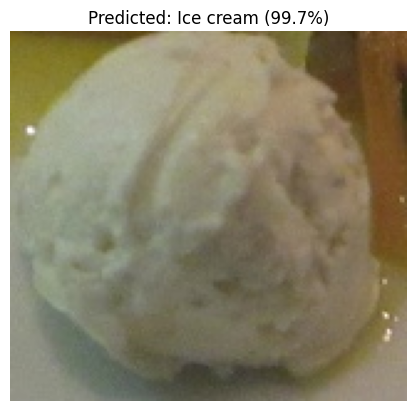

Candy: 0.3%
Coffee: 0.0%
Ice cream: 99.7%


In [14]:
import matplotlib.pyplot as plt
from PIL import Image
import torch

# demonstration function for prediction that also prints image 
def predict_image(model, image_path, transform):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(tensor)
        probs = torch.softmax(output, dim=1)[0]
        pred_idx = probs.argmax().item()
        
    class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
    
    plt.imshow(img)
    plt.title(f"Predicted: {class_names[pred_idx]} ({probs[pred_idx]:.1%})")
    plt.axis("off")
    plt.show()

    for name, prob in zip(class_names, probs):
        print(f"{name}: {prob:.1%}")

test_image_path = test_dataset.dataset.samples[test_dataset.indices[0]][0]
predict_image(model_pretrained, test_image_path, base_transform)

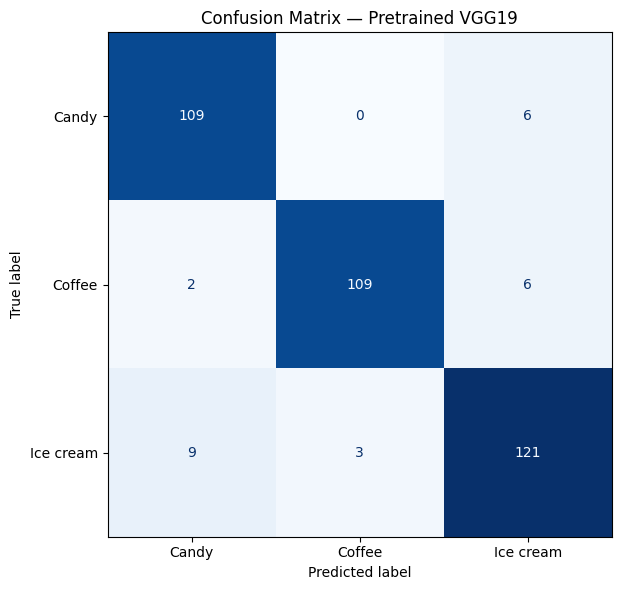

In [15]:
# confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

def plot_confusion_matrix(model, loader, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

    fig, ax = plt.subplots(figsize=(8, 6))
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    plt.title("Confusion Matrix — Pretrained VGG19")
    plt.tight_layout()
    plt.show()

class_names = [k for k, v in sorted(full_dataset.class_to_idx.items(), key=lambda x: x[1])]
plot_confusion_matrix(model_pretrained, test_loader, class_names)

## Experiments with Data Augmentation

In [ ]:
# random rotate, random translate, random crop

## Experiments with Architecture

Rebuild VGG19. After layer block4_conv4 (32, 32,
512):
● Add the following bottleneck layer (padding same)
● Add conv layer (kernel 1x1, filters 1024, padding valid, stride 1, activation
leaky relu)
● Add conv layer (kernel 3x3, filters 1024, padding same, stride 1, activation
relu)
● Freeze conv3 layers and before
● Prediction head (Flatten and fully connected layers)